In [80]:
import math
import numpy as np
from scipy.stats import chi2
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

Part 1

In [81]:
# Select n points in the plane
rng = np.random.default_rng(30)
n = 30
cities = rng.random((n,2))

In [82]:
# Use the Euclidean distance between the points as the cost function.

rng = np.random.default_rng(30)

def cost(route, cities):
    cost = 0

    for i in range(len(route)):                     # walk along the whole route
        now = cities[route[i]]
        next = cities[route[(i + 1) % len(route)]]  # close the route
        cost += np.linalg.norm(next - now)          # euclidean distance

    return cost

In [83]:
# Generate proposals by swapping two randomly selected points on the route

rng = np.random.default_rng(30)

def propose_swap(route, rng):
    new_route = route.copy()

    i, j = rng.choice(len(route), size=2, replace=False)        # pick randomly two distinct indices
    new_route[i], new_route[j] = new_route[j], new_route[i]     # swap them

    return new_route

In [84]:
# Apply a cooling scheme

def cooling_sqrt(k):
    return 1.0 / np.sqrt(1 + k)

def cooling_log(k):
    return 1.0 / np.log(2 + k)

In [85]:
# As a sanity check, test the algorithm using points located on a circle.

theta = np.linspace(0, 2*np.pi, n, endpoint=False)
cities_circle = np.c_[np.cos(theta), np.sin(theta)]

Best cost (random points): 5.249638663468387


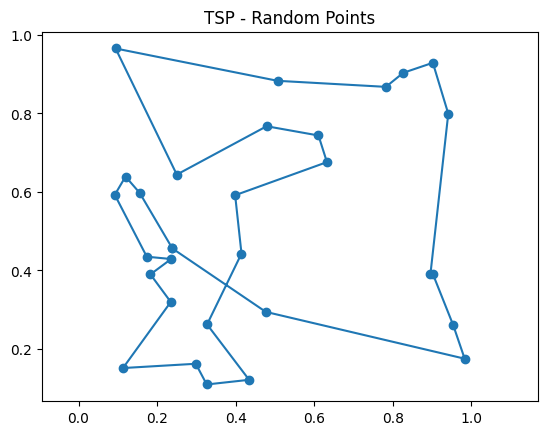

Best cost (circle): 6.271707796059207


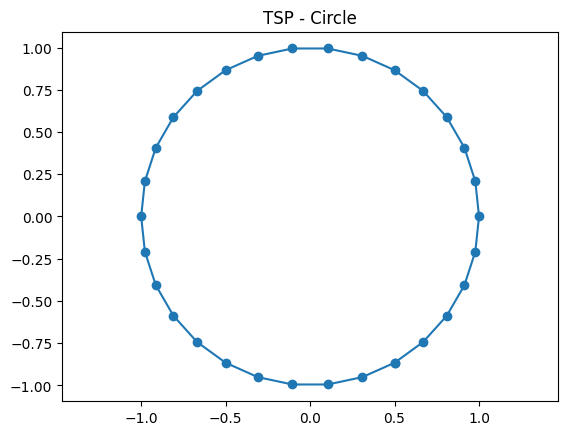

In [86]:
# test the algorithm

rng = np.random.default_rng(30)

def simulation(cities, steps, rng):
    n = len(cities)
    route = rng.permutation(n)
    current_cost = cost(route, cities)

    best_route = route.copy()
    best_cost = current_cost

    costs = []

    for k in range(1, steps):
        T = cooling_sqrt(k)
        # T = cooling_log(k)

        proposal = propose_swap(route, rng)
        prop_cost = cost(proposal, cities)

        delta = prop_cost - current_cost

        # Metropolis acceptance
        if delta < 0 or rng.random() < np.exp(-delta / T):
            route = proposal
            current_cost = prop_cost

            if current_cost < best_cost:
                best_route = route.copy()
                best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs

# Plot the resulting route in the plane.
def plot_tour(cities, route, title="TSP tour"):
    closed = np.append(route, route[0])
    path = cities[closed]

    plt.figure()
    plt.plot(path[:, 0], path[:, 1], "-o")
    plt.title(title)
    plt.axis("equal")
    plt.show()

steps = 20000

# Case 1: random points
best_tour, best_cost, costs = simulation(cities, steps, rng)
print("Best cost (random points):", best_cost)
plot_tour(cities, best_tour, "TSP - Random Points")

# Case 2: circle sanity check
best_tour_c, best_cost_c, costs_c = simulation(cities_circle, steps, rng)
print("Best cost (circle):", best_cost_c)
plot_tour(cities_circle, best_tour_c, "TSP - Circle")

Part 2

In [87]:
def new_cost(route, cost_matrix):
    m = len(route)
    cost = sum(cost_matrix[route[i], route[(i+1) % m]] for i in range(m))
    return cost

In [91]:
cost_matrix = np.loadtxt("cost.csv", delimiter=",")
n = cost_matrix.shape[0]

In [89]:
rng = np.random.default_rng(30)

def simulate2(steps, rng):
    route = rng.permutation(n)
    best_route = route.copy()

    best_cost = new_cost(route, cost_matrix)
    current_cost = best_cost

    for k in range(1, steps):
        T = cooling_sqrt(k)
        # T = cooling_log(k)

        proposal = propose_swap(route, rng)
        prop_cost = new_cost(proposal, cost_matrix)

        delta = prop_cost - current_cost

        # Metropolis acceptance
        if delta < 0 or rng.random() < np.exp(-delta / T):
            route = proposal
            current_cost = prop_cost

            if current_cost < best_cost:
                best_route = route.copy()
                best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs

steps = 20000
best_route, best_cost, costs = simulate2(steps, rng)
print("Best cost:", best_cost)

Best cost: 1171.0
